# Mobile Game Product IAP & Ad Monetization Analytics
- Understanding player engagement, advertising monetization, and long-term player value

### Core business question
> **How should a mobile game optimize in-app purchases and rewarded advertising to increase monetization and long-term player value without damaging player engagement and retention?**
>
Acquisition → Engagement → Ad exposure → Monetization → Retention → LTV

#### 1. In-App Purchase Monetization Funnel & Diagnostic Analysis
#### 2. Ad Monetization Funnel & Diagnostic Analysis
#### 3. Acquisition channel → retention/LTV

# 1. In-App Purchase Monetization Funnel & Diagnostic Analysis
### Business Question

> **Where are the biggest opportunities to increase in-app purchase (IAP) revenue by improving player conversion, purchase frequency, and payer value across platforms, acquisition channels, countries, and player lifecycle stages?**
> 

The goal is to move beyond simply measuring total IAP revenue and **understand why some player cohorts generate more IAP value than others.**
- The analysis decomposes IAP revenue into three fundamental drivers:
 - IAP Revenue = Number of Players × Payer Conversion × Revenue per Payer
- And for payers:
 - Revenue per Payer = Purchase Frequency × Average Revenue per Purchase
### Hypothesis

- **H1:** (High installs ≠ high monetization quality) A meaningful share of active/engaged players generates no IAP revenue, **suggesting that converting engaged players into first-time purchasers is a larger opportunity** than simply increasing spend among existing payers.

- **H2:** IAP monetization efficiency varies significantly across **acquisition channels**.

- **H3:** (IAP and ad monetization ≠ substitutes) **Hybrid monetizers** generate higher total revenue and LTV than players monetized exclusively through ads or IAP.
    - -> players can be (1) IAP-only, (2) Ad-only, (3) Hybrid monetizers, and (4) Non-monetizers
    - (3) Hybrid monetizers can be the biggest monetizing opportunity

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
df = pd.read_csv('/Users/asamitakeuchi/Downloads/Data/mobile-game-ltv-forecasting-challenge/train.csv')

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_26843/4108302586.py:1: DtypeWarning: Columns (10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/asamitakeuchi/Downloads/Data/mobile-game-ltv-forecasting-challenge/train.csv')


## Exploratory analysis

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21006238 entries, 0 to 21006237
Data columns (total 15 columns):
 #   Column             Dtype  
---  ------             -----  
 0   user_id            int64  
 1   platform           object 
 2   country_tier       object 
 3   channel_tier       object 
 4   install_day        int64  
 5   install_week       int64  
 6   day_since_install  int64  
 7   event_hour         int64  
 8   event_type         object 
 9   event_name         object 
 10  product_id         object 
 11  network            object 
 12  ad_placement       object 
 13  revenue_usd        float64
 14  ltv_d8_d180        float64
dtypes: float64(2), int64(5), object(8)
memory usage: 2.3+ GB


- **channel_tier**: Install media source. Channels with fewer than 50 users are grouped as other
- **install_day**: Days since the earliest install in the sample.
- **install_week**: install_day // 7
- **event_type**: Event category: session, iap (In-App Purchase), or ad_impression
- **event_name**: specific event: session_start, af_purchase / in_app_purchase, or ad format (ad_reward, ad_interstitial, etc.)
- - *Rewarded ads* are an opt-in advertising format where **users choose to watch a video, play a mini-game, or complete a survey in exchange for a tangible reward** within an app or website
- **product_id**: Purchased item ID (af_content_id for af_purchase, af_product_id otherwise). **Empty for non-IAP events.**
- **network**: Ad network name. Empty for non-ad events.
- - An advertising network is a technology business that connects companies wanting to display ads (advertisers) with website or app owners who have space available to show them.
- **ad_placement**: Ad placement name. Empty for non-ad events.
- - Ad placement is the specific location on a webpage, app, or social media platform where an advertisement appears
- **revenue_usd**: Revenue in USD for IAP or ad impression events. NaN for session events.

In [13]:
df.head()

,user_id,platform,country_tier,channel_tier,install_day,install_week,day_since_install,event_hour,event_type,event_name,product_id,network,ad_placement,revenue_usd,ltv_d8_d180
0,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000331,6.644226
1,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,b98072a5,9e17b867,0.000226,6.644226
2,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000281,6.644226
3,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000356,6.644226
4,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,4710c070,018933a5,0.000322,6.644226


In [25]:
df.groupby(['event_type','event_name']).user_id.count()

event_type     event_name   
ad_impression  ad_reward        18590666
iap            af_purchase         56060
session        session_start     2359512
Name: user_id, dtype: int64

In [ ]:
# Ttl IAP vs ad_impression rev & LTV


In [52]:
df.groupby(['event_type','event_name', 'network', 'ad_placement', 'channel_tier']).user_id.count()

event_type     event_name  network   ad_placement  channel_tier
ad_impression  ad_reward   0f95c3e4  5c3d47b6      0487c9df        6422
                                                   0a0ae9c4         950
                                                   0a1068d4         441
                                                   1e3b259e         133
                                                   3bc36bb9         660
                                                                   ... 
                           c2b68400  56d1d951      96e2a77d           1
                                                   a9603bc5           3
                                                   bb16a88d        4333
                                                   be8c018e         217
                                                   other            755
Name: user_id, Length: 257, dtype: int64

## Funnel Analysis
- **H1:** (High installs ≠ high monetization quality) A meaningful share of active/engaged players generates no IAP revenue, **suggesting that converting engaged players into first-time purchasers is a larger opportunity** than simply increasing spend among existing payers.

### The In-App Purchase (IAP) funnel at the player/event level
1. **Installed Players** = unique users who installed the game → user_id, platform, country_tier, channel_tier, install_week
2. **Active Players:** = users with ≥1 session_start
3. **Engaged Players** = active users meeting an engagement threshold → e.g. ≥2 active days or ≥X sessions during the observation window
4. **IAP Payers** = unique users with ≥1 event_type = IAP → measures payer conversion
5. **Repeat Payers** = users with ≥2 IAP transactions → measures purchase frequency / retention of monetization
6. **IAP Revenue** = total revenue_usd from event_type = IAP → measures total IAP monetization

#### 1. **Installed Players** = unique users who installed the game → user_id, platform, country_tier, channel_tier, install_week
#### 2. **Active Players:** = users with ≥1 session_start

In [21]:
# Installed Players
unique_users = df['user_id'].nunique()

# Active Players = user_id with >= 1 session_start
active_users = df.loc[df['event_name'] == 'session_start', 'user_id'].nunique()

print(f'Number of Unique installed users:', unique_users)
print(f'Number of Active Players:', active_users)

Number of Unique installed users: 75464
Number of Active Players: 61800


#### 3. **Engaged Players** = active users meeting an engagement threshold → e.g. ≥2 active days or ≥X sessions during the observation window
#### 4. **IAP Payers** = unique users with ≥1 event_type = IAP → measures payer conversion

In [93]:
# 3. Engaged Players = active users meeting an engagement threshold → e.g. ≥2 active days or ≥X sessions during the observation window
# Session-start events only
sessions = df[df['event_name'] == 'session_start'].copy()

# Count distinct active days per user
active_days = (
    sessions
    .groupby('user_id')['day_since_install']
    .nunique()
)

# Engaged players = users active on >= 2 distinct days
engaged_player = (active_days >= 2).sum()

print(f'Number of Engaged Players: {engaged_player}')

Number of Engaged Players: 29231


In [39]:
# 4 IAP payers
iap_users = df.loc[df['event_type'] == 'iap', 'user_id'].nunique()

# Reward / Ad Format Exposure 
iap_ex = df[df['event_type'] == 'iap'].groupby(['event_type', 'ad_placement']).user_id.count().sort_values(ascending=False)

network_ex = df.groupby(['event_type', 'network']).user_id.count().sort_values(ascending=False)

# ad_exposed_users X channel_tier OR ad_placement
print(f'Number of IAP Payers:', iap_users)
print(f'Exposure to Ad Placement:', iap_ex)
print(f'Exposure by Network:', network_ex )

Number of IAP Payers: 5738
Exposure to Ad Placement: Series([], Name: user_id, dtype: int64)
Exposure by Network: event_type     network 
ad_impression  b98072a5    3389494
               8ef7ca0d    2826755
               c2b68400    2428761
               54b36581    2155739
               4710c070    1787085
               ba78355e    1457586
               29a106dd    1209421
               0f95c3e4    1206359
               48dbfa82     707286
               62865ca7     653517
               6fa365a1     453879
               72ffa408     314784
Name: user_id, dtype: int64


#### 5. Repeat Payers = users with ≥2 IAP transactions → measures purchase frequency / retention of monetization
#### 6. IAP Revenue = total revenue_usd from event_type = IAP → measures total IAP monetization

In [87]:
# 5. Repeat Payers = users with ≥2 IAP transactions → measures purchase frequency / retention of monetization
iap_counts = (
    df[df['event_type'] == 'iap']
    .groupby('user_id')
    .size()
    .reset_index(name='iap_transactions')
)
iap_counts['purchase_segment'] = np.select(
    [
        iap_counts['iap_transactions'] == 1,
        iap_counts['iap_transactions'] == 2,
        iap_counts['iap_transactions'] > 2
    ],
    [
        '1-time purchaser',
        '2-time purchaser',
        'Repeat purchaser (>2)'
    ],
    default='Other')
    
purchase_summary = (
    iap_counts
    .groupby('purchase_segment')
    .agg(
        users=('user_id', 'nunique'),
        avg_transactions=('iap_transactions', 'mean'),
        total_transactions=('iap_transactions', 'sum')
    )
    .reset_index()
)

purchase_summary

,purchase_segment,users,avg_transactions,total_transactions
0,1-time purchaser,2176,1.000000,2176
1,2-time purchaser,938,2.000000,1876
2,Repeat purchaser (>2),2624,19.820122,52008


In [45]:
# 6. IAP Revenue = total revenue_usd from event_type = IAP → measures total IAP monetization
iap_monetized_impressions = df.loc[df['event_type'] == 'iap', 'revenue_usd'] > 0
num_iap = len(df[df['event_type'] == 'iap'])
ttl_iap_revenue = df.loc[df['event_type'] == 'iap', 'revenue_usd'].sum()

print(f'Impressions generating revenue:', len(iap_monetized_impressions))
print(f'Ttl ad impressions:', num_iap)
print(f'Ttl ad revenue/impression:', round(ttl_iap_revenue/len(iap_monetized_impressions), 6))
print(f'eCPM (the total ad revenue earned for every 1,000 ad impressions):', round((ttl_iap_revenue/len(iap_monetized_impressions)*1000.00), 2))

Impressions generating revenue: 56060
Ttl ad impressions: 56060
Ttl ad revenue/impression: 12.723176
eCPM (the total ad revenue earned for every 1,000 ad impressions): 12723.18


### Visualizaton of Funnel

In [99]:
stages = {
    "Installed Players":        unique_users,
    "Active Players":           active_users,   # >=1 session_start
    "Engaged Players":       engaged_player,   # >=1 ad impression
    "IAP payers": iap_users,   
    "Repeat Payers (>2)":   2624,   # impressions generating revenue
}

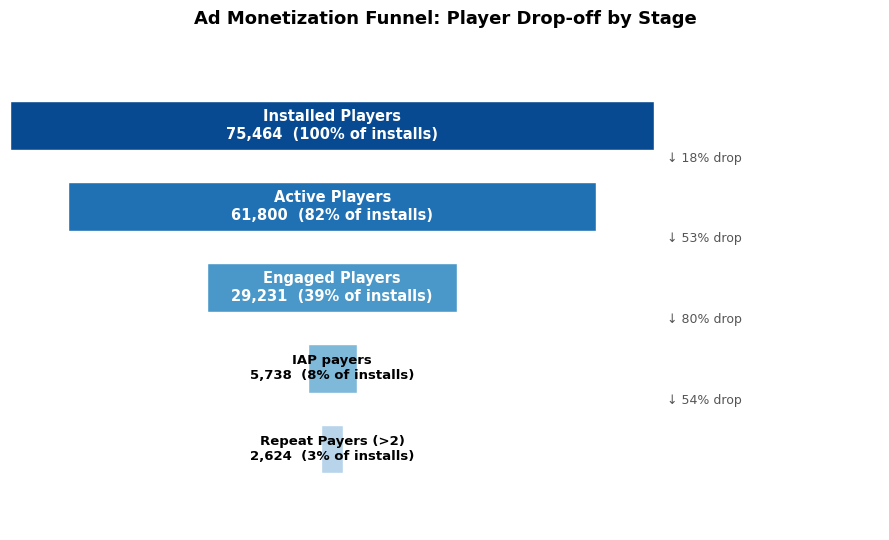

In [103]:
labels = list(stages.keys())
values = list(stages.values())
max_val = values[0]
 
fig, ax = plt.subplots(figsize=(9, 5.5))
 
bar_height = 0.6
y_positions = range(len(labels))[::-1]  # top to bottom
 
colors = plt.cm.Blues([0.9 - 0.15 * i for i in range(len(labels))])
 
for i, (label, value, y) in enumerate(zip(labels, values, y_positions)):
    width = value / max_val
    # center the bar to create the funnel taper effect
    left = (1 - width) / 2
    ax.barh(y, width, left=left, height=bar_height, color=colors[i], edgecolor="white")
 
    pct_of_total = value / max_val * 100
    # value + % label inside/at end of bar
    # Use black text for the smaller bottom stages
    font_color = "black" if label in ["IAP payers", "Repeat Payers (>2)"] else "white"
    font_size = 9.5 if label in ["IAP payers", "Repeat Payers (>2)"] else 10.5
    
    ax.text(
        0.5, y,
        f"{label}\n{value:,}  ({pct_of_total:.0f}% of installs)",
        ha="center",
        va="center",
        fontsize=font_size,
        color=font_color,
        fontweight="bold"
    )
     
    # drop-off annotation between stages
    if i > 0:
        prev_value = values[i - 1]
        drop_pct = (1 - value / prev_value) * 100
        ax.text(1.02, y + bar_height / 2 + 0.3, f"↓ {drop_pct:.0f}% drop",
                ha="left", va="center", fontsize=9, color="#555555")
 
ax.set_xlim(0, 1.35)
ax.set_ylim(-1, len(labels))
ax.axis("off")
ax.set_title("Ad Monetization Funnel: Player Drop-off by Stage",
             fontsize=13, fontweight="bold", pad=15)
 
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/funnel_dropoff.png", dpi=200, bbox_inches="tight")
# print("Saved funnel_dropoff.png")

## H2: IAP monetization efficiency varies significantly across acquisition channels.

In [68]:
# map hypothetical channels
# map hypothetical names
channel_map = {
    '92247aa9': 'Google Ads / UAC',
    'bb16a88d': 'Meta Ads',
    '8ad56f16': 'TikTok Ads',
    '0487c9df': 'Unity Ads',
    '3bc36bb9': 'AppLovin',
    '1e3b259e': 'ironSource / LevelPlay',
    '0a1068d4': 'Liftoff / Vungle',
    '62eb5cc1': 'Moloco',
    '0a0ae9c4': 'Pangle',
    'other': 'Other',
    'c7b4e5c9': 'Mintegral',
    'be8c018e': 'Digital Turbine',
    '96e2a77d': 'Apple Search Ads',
    'a9603bc5': 'Snap Ads',
    '249fc9c1': 'Reddit Ads',
    'a4ec9600': 'Other DSP'
}

df['acquisition_channel_name'] = (
    df['channel_tier'].map(channel_map)
)

In [72]:
df[df['event_type'] == 'iap'].groupby(['acquisition_channel_name']).agg({'user_id':'count', 'revenue_usd': 'sum', 'ltv_d8_d180':'mean'}).sort_values(by= 'revenue_usd', ascending=False)

,user_id,revenue_usd,ltv_d8_d180
acquisition_channel_name,,,
Google Ads / UAC,28565,326724.615733,1110.499205
Meta Ads,19820,255303.765308,1249.577806
Pangle,1547,70341.588080,25116.280412
TikTok Ads,2574,25021.441344,277.059735
Liftoff / Vungle,825,9734.751727,6664.337441
Unity Ads,868,7691.886918,141.447693
ironSource / LevelPlay,632,7426.460302,186.652702
AppLovin,563,5939.139309,151.708053
Other,266,1928.647668,226.301364


## H6: (IAP and ad monetization ≠ substitutes) Hybrid monetizers generate higher total revenue and LTV than players monetized exclusively through ads or IAP.

-> players can be (1) IAP-only, (2) Ad-only, (3) Hybrid monetizers, and (4) Non-monetizers
(3) Hybrid monetizers can be the biggest monetizing opportunity

In [75]:
# Create user-level monetization flags
user_monetization = (
    df.groupby('user_id')
      .agg(
          has_iap=('event_type', lambda x: (x == 'iap').any()),
          has_ad=('event_type', lambda x: (x == 'ad_impression').any())
      )
      .reset_index()
)

# Assign monetization segment
user_monetization['monetization_type'] = np.select(
    [
        user_monetization['has_iap'] & ~user_monetization['has_ad'],
        ~user_monetization['has_iap'] & user_monetization['has_ad'],
        user_monetization['has_iap'] & user_monetization['has_ad']
    ],
    [
        'IAP-only',
        'Ad-only',
        'Hybrid'
    ],
    default='Non-monetizer'
)

user_monetization.head()

,user_id,has_iap,has_ad,monetization_type
0,1,False,True,Ad-only
1,2,False,True,Ad-only
2,3,False,True,Ad-only
3,4,False,True,Ad-only
4,5,False,True,Ad-only


In [77]:
df_segmented = df.merge(
    user_monetization[['user_id', 'monetization_type']],
    on='user_id',
    how='left'
)

In [79]:
user_level = (
    df_segmented
    .groupby(['user_id', 'monetization_type'])
    .agg(
        total_revenue=('revenue_usd', 'sum'),
        ltv_d8_d180=('ltv_d8_d180', 'first')
    )
    .reset_index()
)

In [83]:
segment_summary = (
    user_level
    .groupby('monetization_type')
    .agg(
        users=('user_id', 'nunique'),
        total_revenue=('total_revenue', 'sum'),
        avg_revenue_per_user=('total_revenue', 'mean'),
        total_ltv=('ltv_d8_d180', 'sum'),
        avg_ltv_per_user=('ltv_d8_d180', 'mean')
    )
    .reset_index().sort_values(by='total_ltv', ascending=False)
)

segment_summary

,monetization_type,users,total_revenue,avg_revenue_per_user,total_ltv,avg_ltv_per_user
1,Hybrid,4326,503905.353316,116.482976,567303.162882,131.138040
2,IAP-only,1412,230661.850093,163.358251,413078.400761,292.548442
0,Ad-only,46769,53966.334494,1.153891,228356.417278,4.882645
3,Non-monetizer,22957,0.000000,0.000000,12412.212577,0.540672
